# Notebook 04: Métricas Intrínsecas de Qualidade: LCI e Completude

Implementa as métricas intrínsecas do pipeline, calculáveis diretamente do CNEFE, sem necessidade do BHMap. LCI operacionaliza NV_GEO_COORD como índice de certeza de localização; Completude mede a proporção de campos críticos preenchidos.


In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import contextily as ctx

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config
from src.metrics import calculate_lci, calculate_completude

gdf_matched = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_matched.parquet')
gdf_bairros = gpd.read_file(config.BAIRROS_SHP)


## 1. LCI e Completude: Implementação

As métricas extrínsecas (MCI, acurácia posicional) requerem o BHMap; as intrínsecas (LCI, Completude) são calculáveis a partir do próprio CNEFE e replicáveis em qualquer município. LCI segue a escala NV_GEO_COORD de Davis & Fonseca (2007): NV=1 → LCI=1,0; NV=2 → LCI=0,8; NV=3 → LCI=0,5; NV=6 → LCI=0,1.

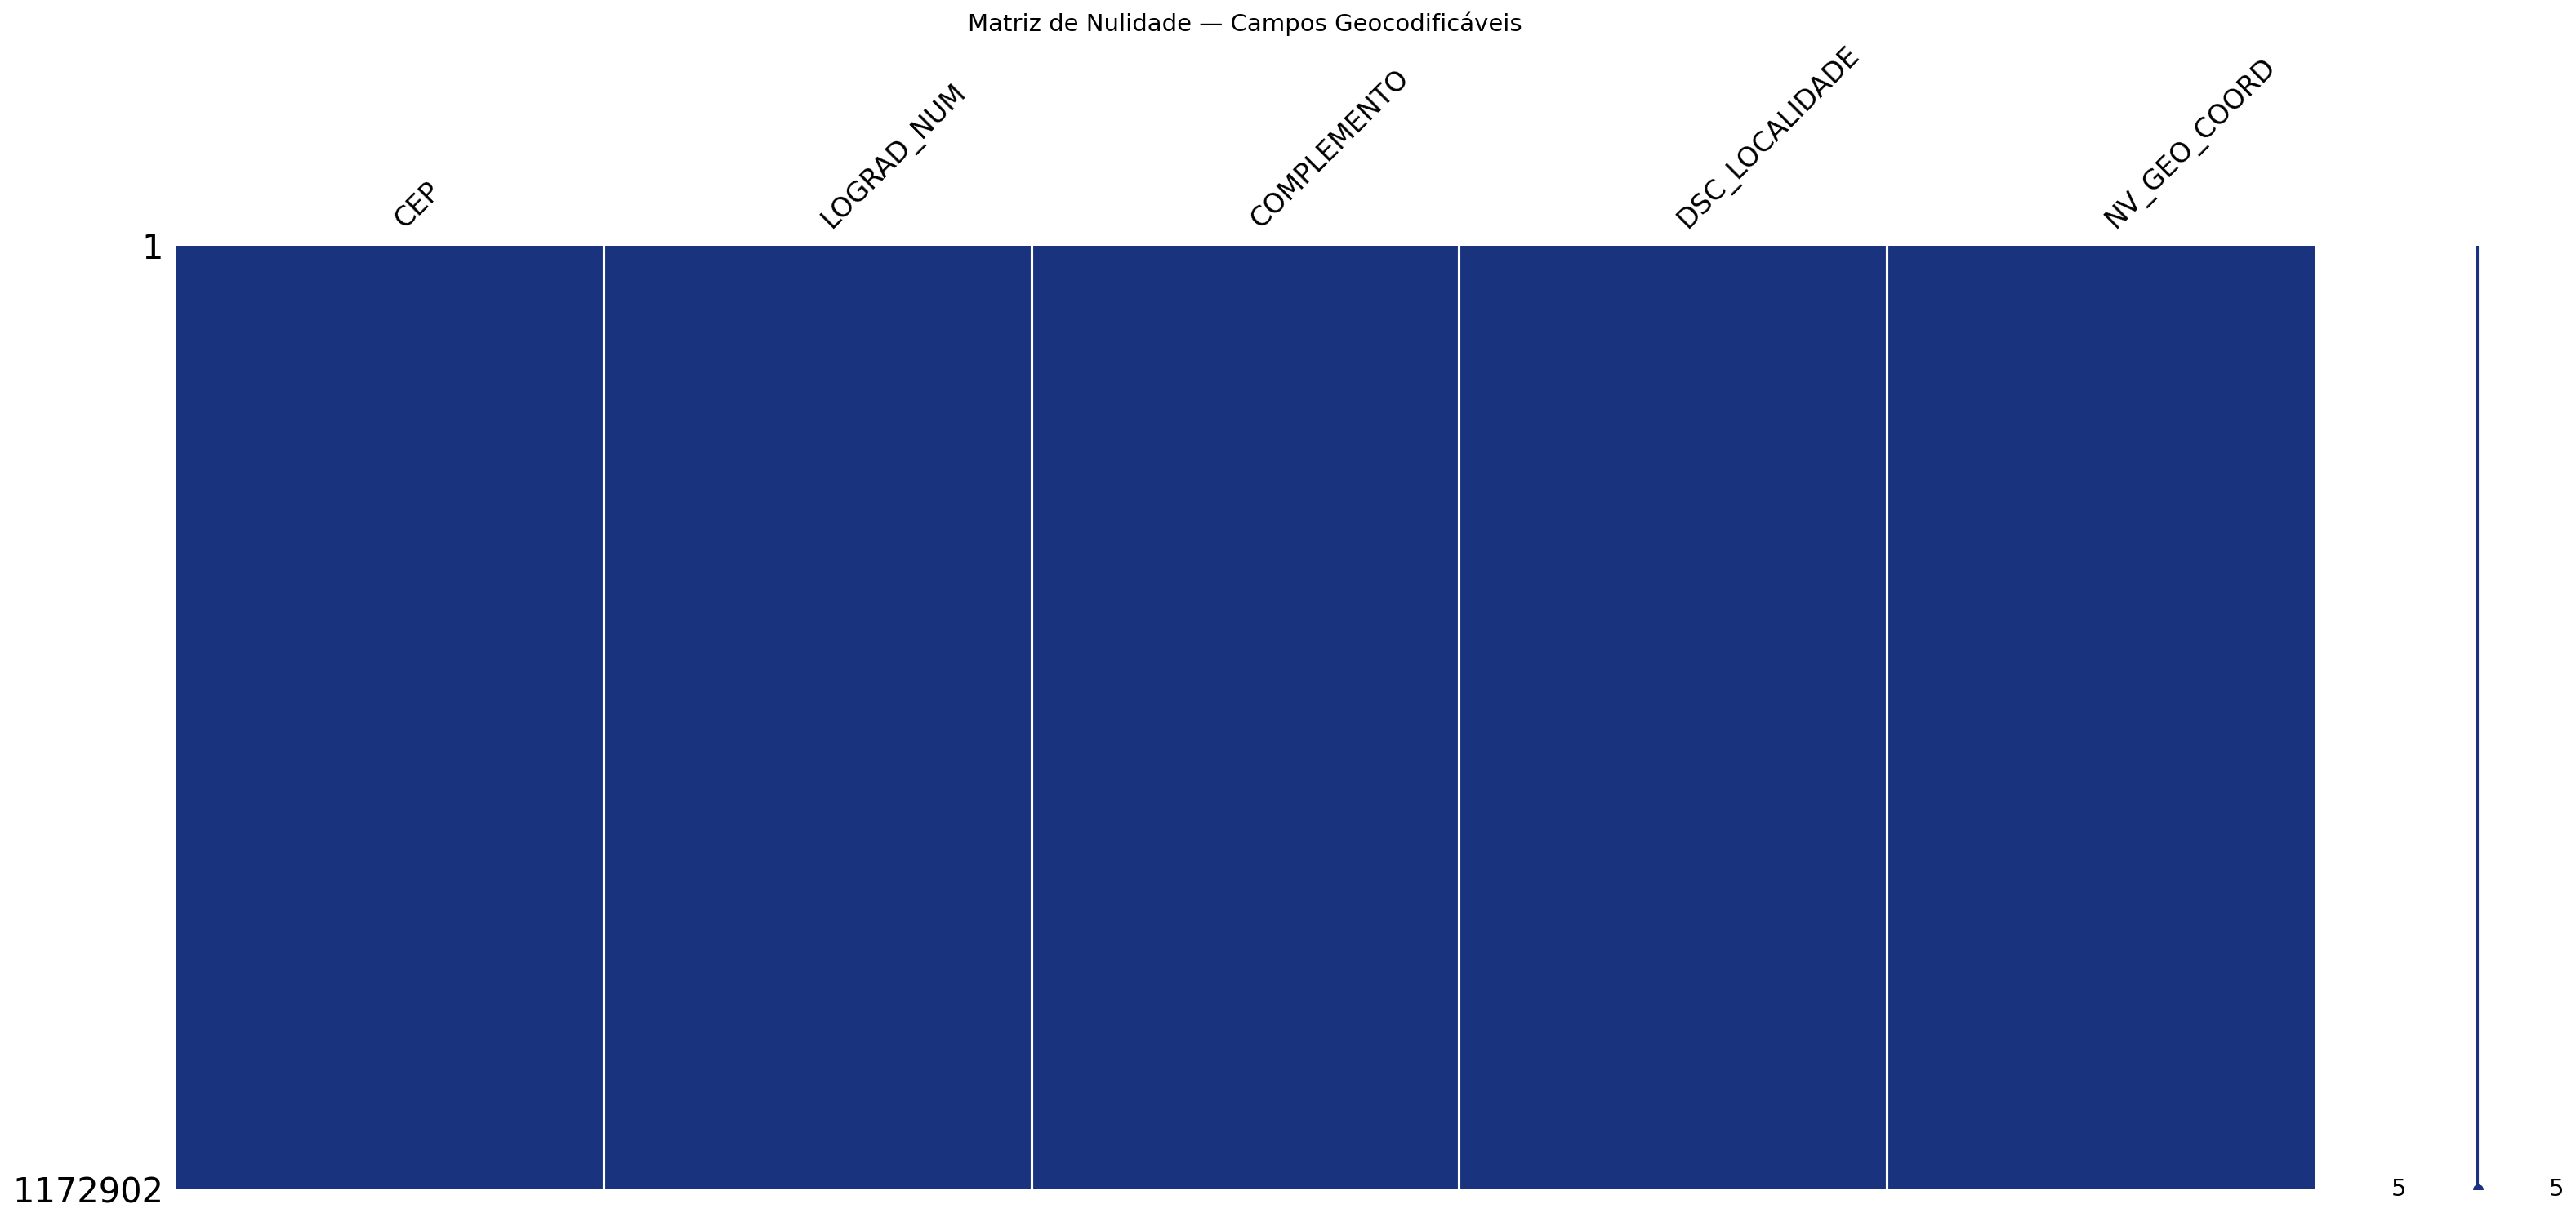

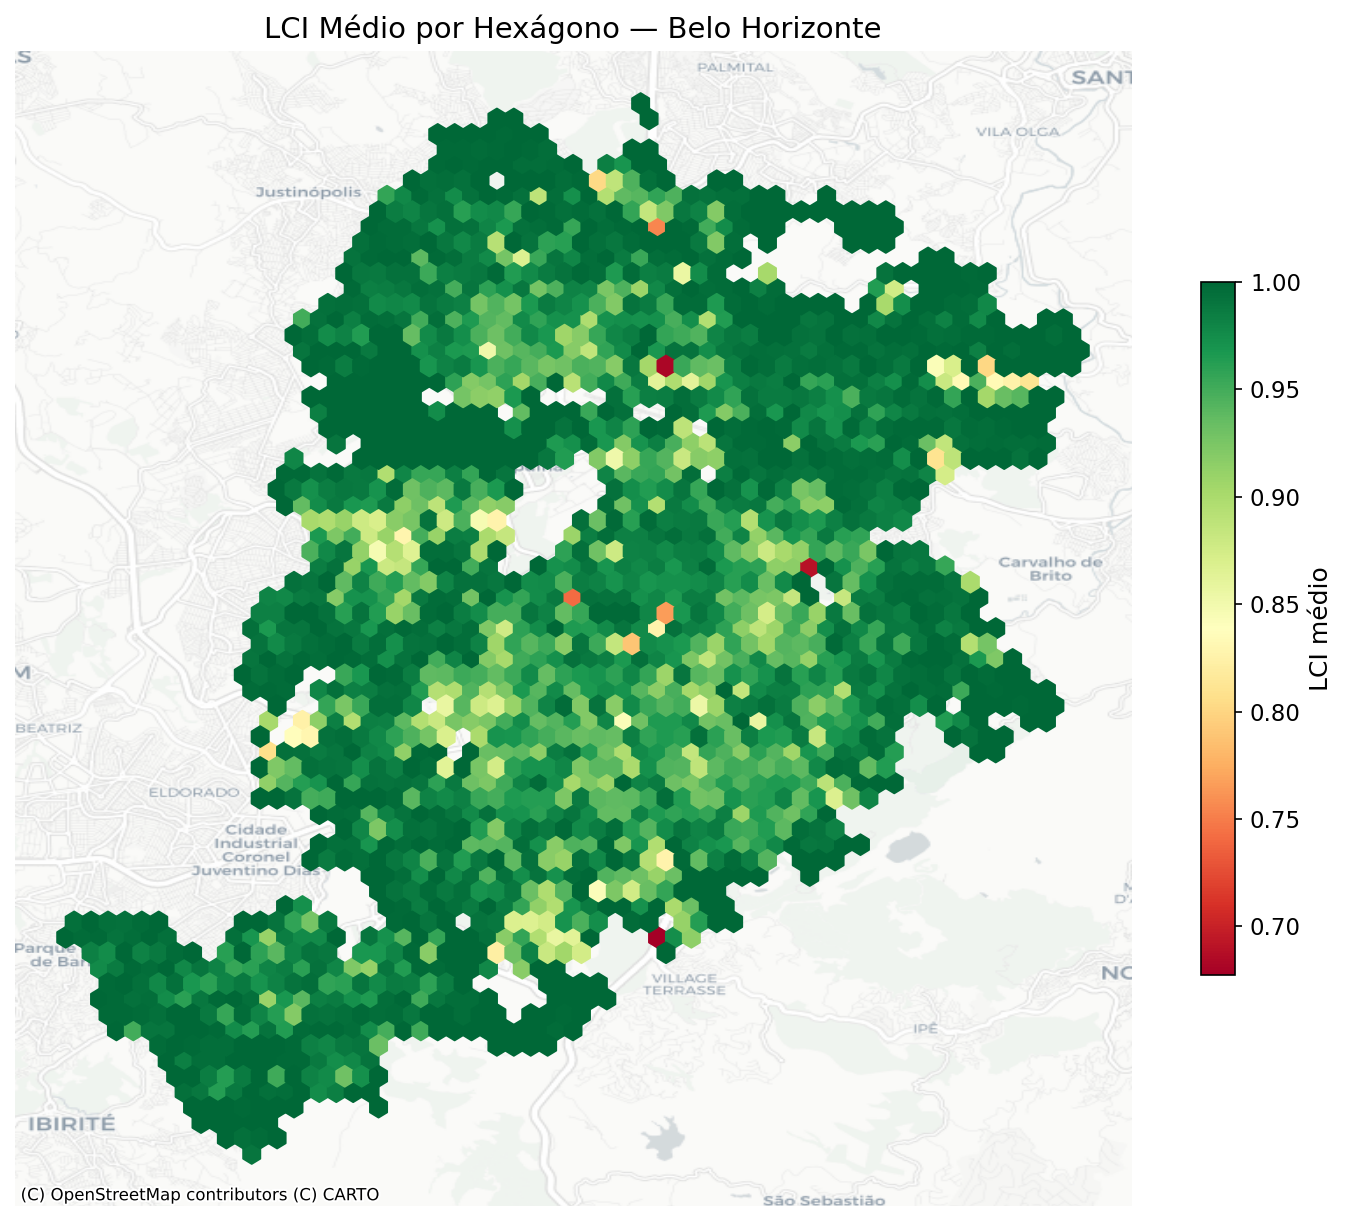

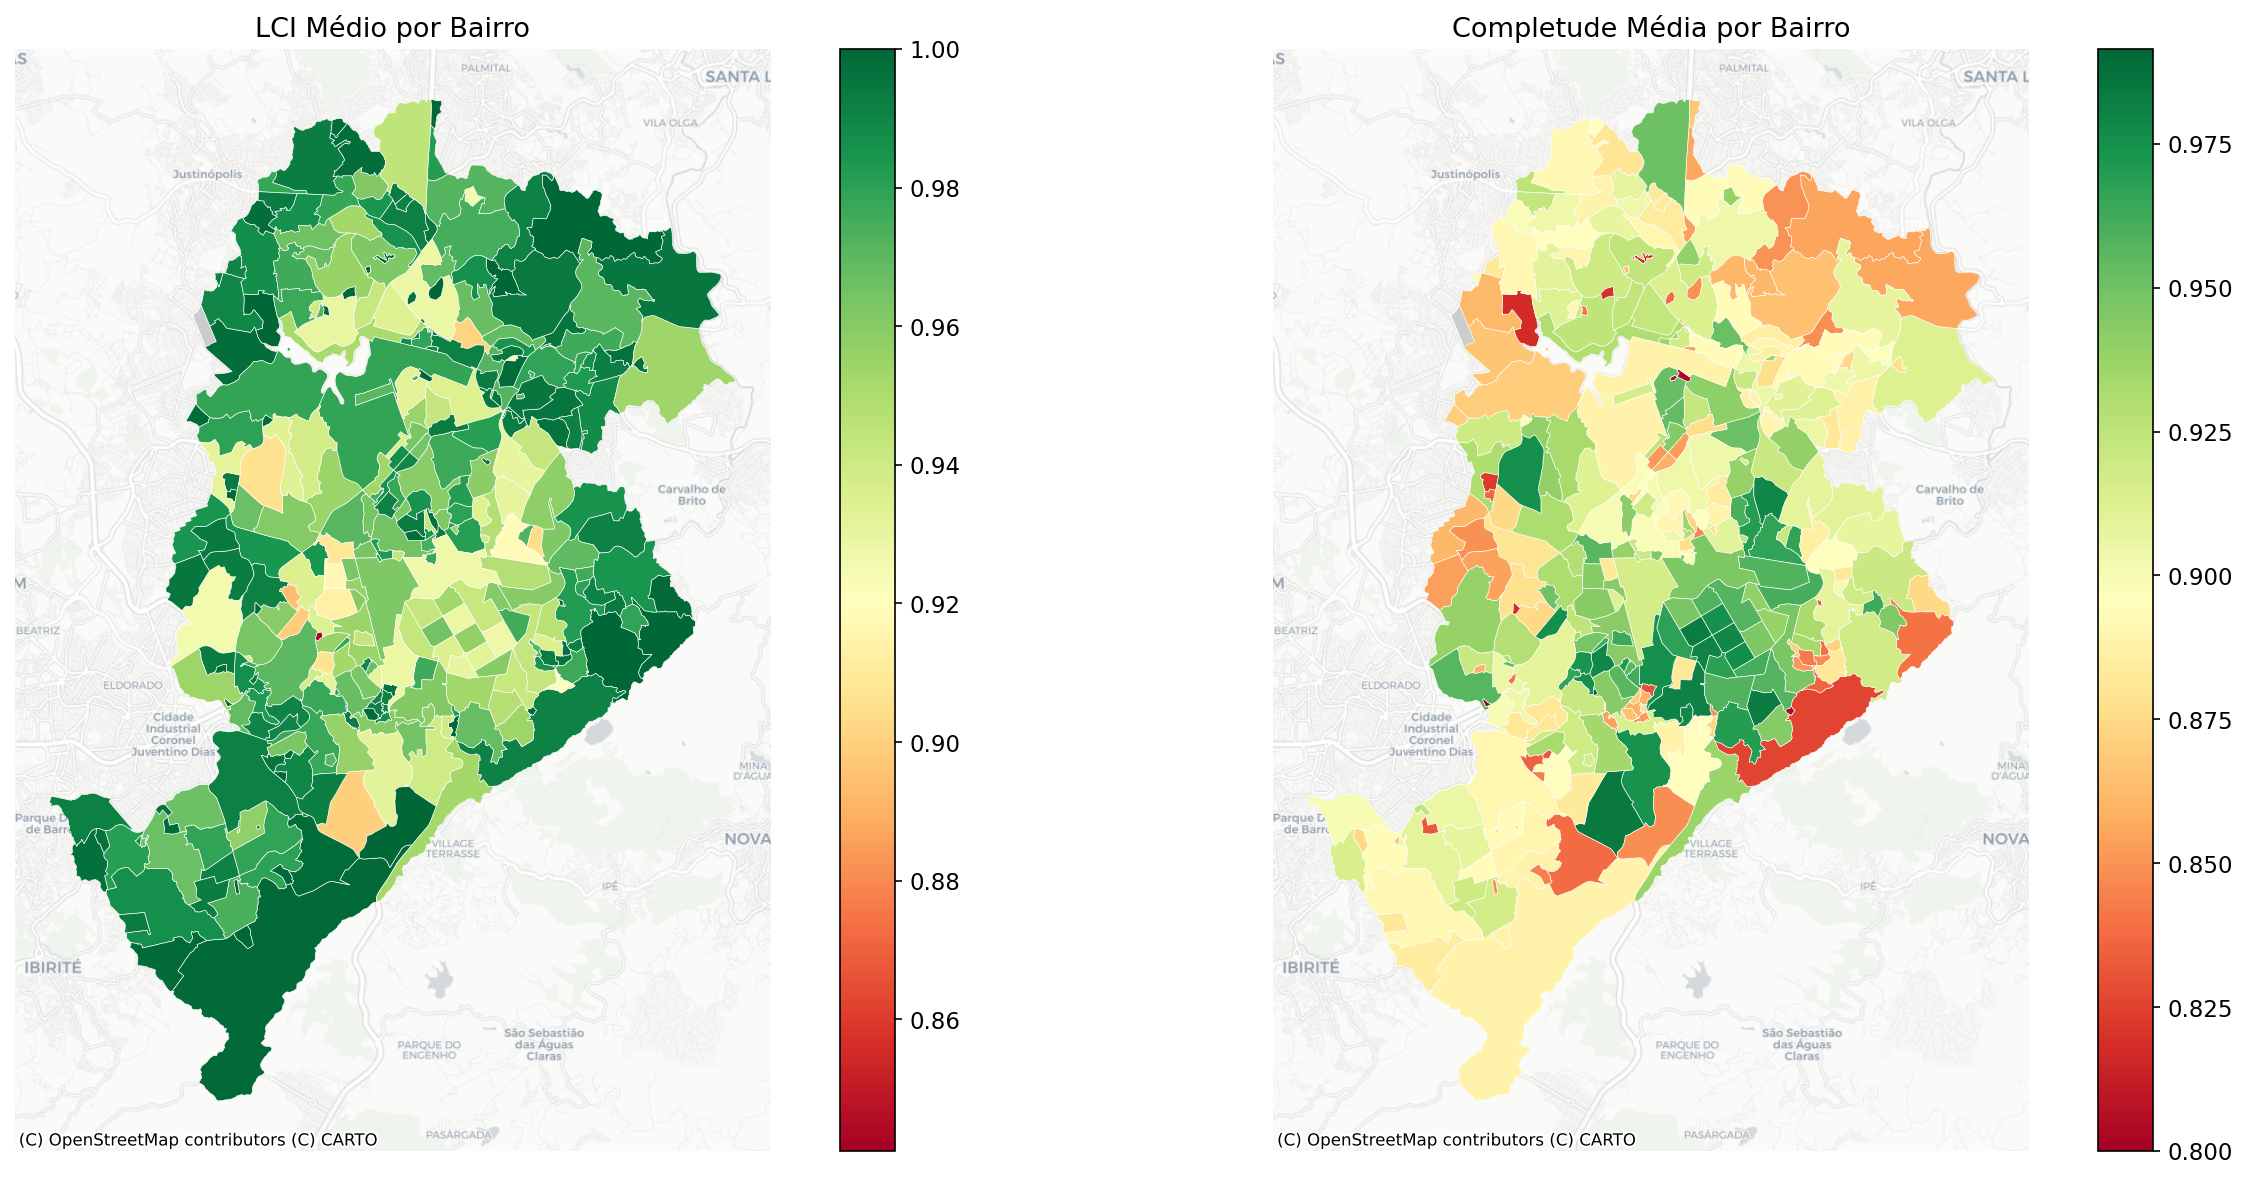

NV_GEO_COORD,NV_desc,n,pct,LCI,COMP_mean
1,Medido em campo,"989,308",84.3%,1.00,0.902
2,Estimado próximo,"171,632",14.6%,0.80,1.000
3,Estimado distante,"8,218",0.7%,0.50,0.966
4,Outro método,"3,741",0.3%,0.30,0.884
6,Sem medição,3,0.0%,0.10,0.800


Salvo: cnefe_pre_gci.parquet (1,172,902 registros)


In [2]:

# Calcular métricas
gdf_matched['COMPLETUDE'] = calculate_completude(gdf_matched)
gdf_matched['LCI'] = calculate_lci(gdf_matched['NV_GEO_COORD'])

# --- 1.1 Matriz de nulidade ---
msno.matrix(gdf_matched[[c for c in config.COMPLETUDE_CAMPOS_PESOS.keys() if c in gdf_matched.columns]], color=(0.1, 0.2, 0.5))
plt.title('Matriz de Nulidade — Campos Geocodificáveis')
plt.savefig(config.FIG_DIR / 'nb04_matrix_nulidade.png', dpi=200, bbox_inches='tight')
plt.show()

# --- 1.2 Hexbin LCI ---
gdf_web = gdf_matched.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(12, 10))
hb = ax.hexbin(gdf_web.geometry.x, gdf_web.geometry.y,
               C=gdf_web['LCI'].values,
               reduce_C_function=np.mean,
               gridsize=60, cmap='RdYlGn', mincnt=5)
plt.colorbar(hb, ax=ax, shrink=0.6, label='LCI médio')
try:
    import contextily as ctx
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    except Exception as e:
        print(f'Warning: Basemap download failed ({e})')
except Exception:
    pass
ax.set_title('LCI Médio por Hexágono — Belo Horizonte')
ax.axis('off')
plt.savefig(config.FIG_DIR / 'nb04_mapa_lci_hexbin.png', dpi=200, bbox_inches='tight')
plt.show()

# --- 1.3 Coroplético por bairro ---
gdf_matched_clean = gdf_matched.drop(columns='index_right', errors='ignore')
gdf_bairros_proj = gdf_bairros.to_crs(gdf_matched_clean.crs)
gdf_with_bairro = gpd.sjoin(gdf_matched_clean, gdf_bairros_proj[['NOME', 'geometry']], how='left', predicate='within')
lci_bairro = gdf_with_bairro.groupby('NOME').agg(
    LCI_mean=('LCI', 'mean'),
    COMP_mean=('COMPLETUDE', 'mean'),
    n=('LCI', 'count')
).reset_index()
gdf_bairros_lci = gdf_bairros_proj.merge(lci_bairro, on='NOME', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, col, title in zip(axes,
                           ['LCI_mean', 'COMP_mean'],
                           ['LCI Médio por Bairro', 'Completude Média por Bairro']):
    gdf_bairros_lci.to_crs(epsg=3857).plot(
        column=col, cmap='RdYlGn', ax=ax, legend=True,
        edgecolor='white', linewidth=0.3, missing_kwds={'color': '#cccccc'})
    try:
        try:
            ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
        except Exception as e:
            print(f'Warning: Basemap download failed ({e})')
    except Exception:
        pass
    ax.set_title(title, fontsize=13)
    ax.axis('off')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb04_coropletico_bairro_lci_completude.png', dpi=200, bbox_inches='tight')
plt.show()

# Estatísticas por NV_GEO_COORD (tabela estilizada)
lci_stats = gdf_matched.groupby('NV_GEO_COORD').agg(
    n=('LCI', 'count'),
    LCI=('LCI', 'first'),
    COMP_mean=('COMPLETUDE', 'mean')
).reset_index()
lci_stats['pct'] = lci_stats['n'] / lci_stats['n'].sum() * 100
lci_stats['NV_desc'] = lci_stats['NV_GEO_COORD'].map(config.NV_GEO_MAP).fillna('Desconhecido')

display(lci_stats[['NV_GEO_COORD', 'NV_desc', 'n', 'pct', 'LCI', 'COMP_mean']].style
    .background_gradient(subset=['n'], cmap='Blues')
    .bar(subset=['pct'], color='#aed6f1', vmin=0, vmax=100)
    .background_gradient(subset=['LCI'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['COMP_mean'], cmap='YlGn', vmin=0, vmax=1)
    .format({'n': '{:,.0f}', 'pct': '{:.1f}%', 'LCI': '{:.2f}', 'COMP_mean': '{:.3f}'})
    .hide(axis='index')
    .set_caption('Estatísticas LCI e Completude por NV_GEO_COORD'))

# Salvar dataset enriquecido
gdf_matched.to_parquet(config.PROCESSED_DIR / 'cnefe_pre_gci.parquet')
print(f"Salvo: cnefe_pre_gci.parquet ({len(gdf_matched):,} registros)")

`CEP` e `COMPLEMENTO` têm as maiores lacunas, concentradas em periferias e assentamentos informais. A ausência de CEP compromete a similaridade textual do MCI; a ausência de COMPLEMENTO impede detecção de verticalização por número de apartamento. Ambas são limitações do dado fonte, não do método de avaliação.

## Conclusão do Notebook 04

Este notebook implementou e validou as métricas intrínsecas de qualidade do pipeline:

- **LCI médio = 0,965** (84,4% dos registros com NV=1): a qualidade formal da coleta GPS do IBGE é alta. O LCI captura uma *decisão metodológica do IBGE*, não ruído aleatório, o que valida seu uso como componente do GCI sem calibração adicional
- **Completude:** lacunas sistemáticas em `COMPLEMENTO` e `CEP` nas periferias e assentamentos informais documentam uma dimensão de qualidade textual parcialmente independente do LCI, um registro pode ter GPS medido em campo (LCI=1,0) e ainda assim ter Completude baixa
- **Divergência espacial LCI × Completude:** Hipercentro/Centro-Sul com LCI ligeiramente menor (alta densidade de NV=2 em apartamentos) mas maior Completude; periferias com melhor LCI mas pior completude textual
- **FLAG_NUMERO_INVALIDO:** 77.494 registros (6,6%) com numeração inválida no BHMap, fator de contaminação silenciosa que afeta o MCI e deve ser declarado como limitação na dissertação